# Прогноз развития торговой точки (бургерная) на 12 месяцев

**Задача.** Есть одна торговая точка. Нужно сгенерировать реалистичный датасет транзакций
(1 точка, 1000 покупателей, 10 000 транзакций, 12 месяцев) и спрогнозировать следующие
12 месяцев с сохранением сезонности.

**Формат данных:** `id точки | id покупателя | id транзакции | оборот покупки | дата`

**Целевые показатели прогноза** : месяц, клиенты в месяц,
количество покупок в месяц, оборот. Средний чек получается как оборот / покупки.

## 1. Стратегия генерации данных

### Главный принцип: оборот не рисуем, а собираем из механики спроса

Наивный путь — сгенерировать оборот как «тренд + случайный шум». Так делать нельзя:
в данных не будет внутренней структуры, и модель потом будет учиться на пустоте.

Мы строим двухслойную модель:

    оборот дня = (сколько чеков пробили) × (какой в среднем чек)
    чеки       = конкретные клиенты, у каждого своя частота посещений

**Слой трафика** — мультипликативная интенсивность. Так спрос устроен в реальности:
суббота даёт «+40%», а не «+50 чеков» — процент работает и в январе, и в июле,
просто от разной базы.

    λ(t) = trend × year_season × weekday × payday × holiday × noise

**Слой клиентов** — главное допущение: точка ЗРЕЛАЯ. Клиентская база стационарна
(приток новых клиентов = оттоку), активная аудитория постоянна весь год. В данных
остаются только эффекты, которые мы и хотим прогнозировать: сезонность, слабый тренд,
инфляция чека.

**Слой чека** — логнормальный, с инфляцией и надбавкой за выходные.

### Импорты и константы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

RNG = np.random.default_rng(7)

D1 = 364                 # год 1
D2 = 364                 # год 2 — "истина будущего", для проверки прогноза
N_DAYS = D1 + D2
N_CUSTOMERS_Y1 = 1000    
N_TX_Y1 = 10000          
SHOP_ID = "SHOP_001"

dates = pd.date_range("2025-07-07", periods=N_DAYS, freq="D")   # старт — понедельник
t = np.arange(N_DAYS)

print("История:", dates[0].date(), "—", dates[D1-1].date(), f"({D1} дней = {D1//7} недель)")

История: 2025-07-07 — 2026-07-05 (364 дней = 52 недель)


Две неочевидные детали:

* **Старт с понедельника и ровно 364 дня** — чтобы получились 52 целые недели без
  «огрызков» на краях. Иначе первая и последняя недели были бы неполными и дали бы
  ложные провалы в ряду.
* **Второй год (D2)** — приём для проверки. Сгенерируем следующие 12 месяцев тем же
  процессом, спрячем от модели, а потом сравним прогноз с этим «настоящим будущим».
  Обычно так проверить нельзя (будущее не наступило), а на синтетике — можно.

In [2]:
# ТРЕНД ТРАФИКА: +7% в год (Росстат даёт +8.7% реального роста оборота общепита за 2025 г.(в это входит открытие новых точек, поэтому для одной точки берём чуть ниже))
trend = 1.0 + 0.07 * (t / D1)

# ГОДОВАЯ СЕЗОННОСТЬ: точка с предновогодним пиком (декабрь) и летним спадом —
# типично для локации в ТЦ / бизнес-районе (летом отпуска, в декабре предпраздничный трафик).
month_factor = {1: 0.80, 2: 0.83, 3: 0.90, 4: 0.95, 5: 1.00, 6: 0.95,
                7: 0.90, 8: 0.92, 9: 1.00, 10: 1.10, 11: 1.20, 12: 1.40}

# сглаживаем ступеньки месяцев в плавную волну. Окно 21 день: декабрьский пик становитсяколоколом (а не плоским плато с обрывом), межмесячные переходы гладкие.
season = pd.Series([month_factor[d.month] for d in dates]).rolling(21, center=True, min_periods=1).mean().values

# НЕДЕЛЬНАЯ СЕЗОННОСТЬ (пн..вс): пик выходного дня
weekday_factor = np.array([0.90, 0.88, 0.92, 1.00, 1.15, 1.35, 1.20])
weekday_factor = weekday_factor / weekday_factor.mean()
weekday = np.array([weekday_factor[d.weekday()] for d in dates])

# ЗАРПЛАТНЫЕ ДНИ: всплеск после аванса (10-е) и зарплаты (25-е)
payday = np.where([d.day in (10, 11, 12, 25, 26, 27) for d in dates], 1.12, 1.0)

# ПРАЗДНИКИ
holiday = np.ones(N_DAYS)
for i, d in enumerate(dates):
    key = (d.month, d.day)
    if d.month == 1 and d.day <= 6:        holiday[i] = 0.65   # новогодние каникулы: город пустой
    elif key in [(3, 8), (5, 9), (6, 12)]: holiday[i] = 1.30   # праздничные выходы
    elif key == (12, 31):                  holiday[i] = 0.70
    elif key in [(2, 14), (12, 30)]:       holiday[i] = 1.20

# ШУМ: погода, случайности. Логнормальный, чтобы множитель всегда был > 0
noise = RNG.lognormal(0, .10, N_DAYS)

lam = trend * season * weekday * payday * holiday * noise
print("Интенсивность трафика: отношение пик/провал = %.1fx" % (lam.max() / lam.min()))

Интенсивность трафика: отношение пик/провал = 4.4x


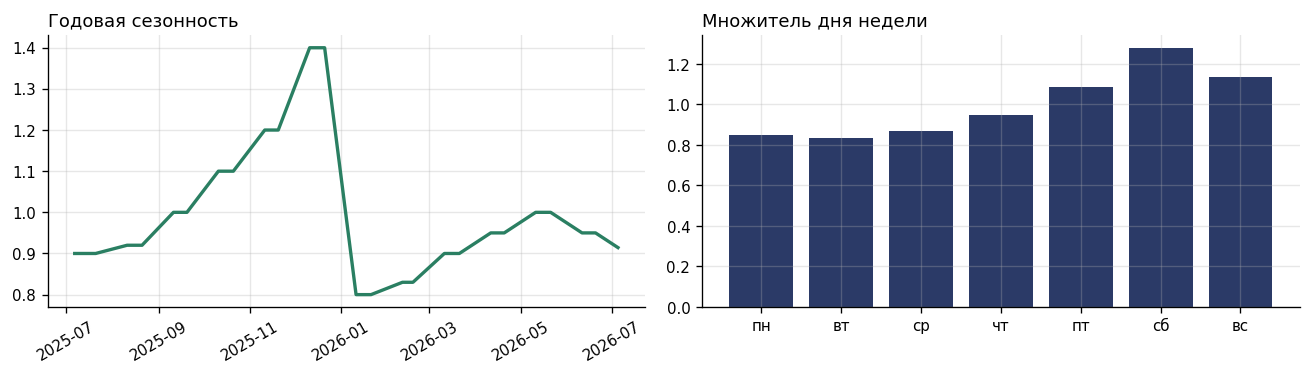

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(dates[:D1], season[:D1], color="#2a7f62", lw=2)
axes[0].set_title("Годовая сезонность", loc="left"); axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(range(7), weekday_factor, color="#2b3a67")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(["пн","вт","ср","чт","пт","сб","вс"])
axes[1].set_title("Множитель дня недели", loc="left")
plt.tight_layout(); plt.show()

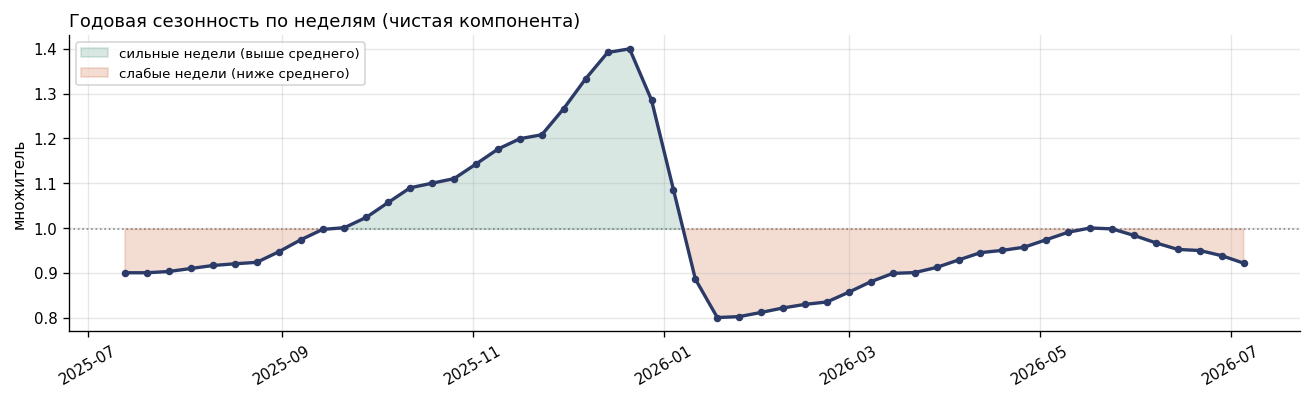

Пик:    2025-12-21  ×1.40
Провал: 2026-01-18  ×0.80


In [4]:
# Годовая сезонность по неделям — чистая сезонная компонента без дня недели, зарплат и шума.
# Недельное усреднение убирает дневную рябь, остаётся плавная годовая волна.
season_only = pd.Series(season, index=dates).iloc[:D1]         # только год 1
season_weekly = season_only.resample("W").mean()

mid = season_weekly.mean()                                     # средний уровень профиля

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(season_weekly.index, season_weekly.values, color="#2b3a67", lw=2, marker="o", ms=3.5, zorder=3)
ax.axhline(mid, color="grey", lw=1, ls=":", zorder=1)

# недели выше среднего — зелёные (сильные), ниже — оранжевые (слабые)
ax.fill_between(season_weekly.index, mid, season_weekly.values,
                where=(season_weekly.values >= mid), color="#2a7f62", alpha=.18,
                interpolate=True, label="сильные недели (выше среднего)")
ax.fill_between(season_weekly.index, mid, season_weekly.values,
                where=(season_weekly.values < mid), color="#c1440e", alpha=.18,
                interpolate=True, label="слабые недели (ниже среднего)")

ax.set_title("Годовая сезонность по неделям (чистая компонента)", loc="left")
ax.set_ylabel("множитель"); ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

print("Пик:    %s  ×%.2f" % (season_weekly.idxmax().date(), season_weekly.max()))
print("Провал: %s  ×%.2f" % (season_weekly.idxmin().date(), season_weekly.min()))

### Принятые параметры и обоснования

| Параметр | Значение | Обоснование |
|---|---|---|
| Тренд трафика | +7%/год | Росстат: рост общепита +8.7% в сопоставимых ценах, но с учётом новых точек; для одной точки — консервативно |
| Инфляция чека | +5%/год | осознанное упрощение: реальные ~15% (INFOLine) маскировали бы сезонность, а она — главный объект изучения |
| Сезонность | пик/провал 1.6x, экспертно | макроданные непригодны: агрегат смешивает сегменты с противофазной сезонностью |
| День недели / зарплаты / праздники | как есть | реалистичность дневного ряда |

## 2. Клиентская база: распределение транзакций по покупателям

Нам нужно распределить 10 000 покупок между 1000 клиентами. Наивный путь — раздать поровну
(каждому по 10) — нереалистичен: в жизни клиенты ходят по-разному. Небольшое ядро завсегдатаев
приносит бóльшую часть чеков, а основная масса заходит редко.

Мы задаём это **законом Парето** через NBD-модель:

* каждому клиенту присваиваем личную частоту посещений λᵢ из **гамма-распределения**;
* малый параметр формы (0.5) делает распределение сильно скошенным: много клиентов с малой
  частотой, мало — с большой;
* при розыгрыше покупок клиент с бóльшей частотой чаще попадает в выборку.

Так закон Парето (топ-20% клиентов дают ~60–70% чеков) возникает **сам собой**, из механики,
а не задаётся руками.

**Допущение о зрелой точке.** Все 1000 клиентов активны весь период — мы не моделируем приток
и отток. Это осознанное упрощение: для одной точки на горизонте года явная текучка базы
избыточна, на сезонность и качество прогноза не влияет, а сложность добавляет. Ключевое
свойство — скошенность частот по Парето — мы сохраняем, потому что именно оно определяет
реалистичный уровень шума в данных: если бы все ходили одинаково часто, ряд был бы неестественно
гладким, и оценка точности модели оказалась бы завышенной.

In [5]:
# 1000 клиентов, у каждого — личная частота посещений из гамма-распределения (NBD-модель).
# Параметр формы 0.5 даёт сильную скошенность
# Клиенты активны весь период (оба года) -> база стабильна по построению, скрытого тренда нет.
cust_rate = np.clip(RNG.gamma(0.5, 1.0, N_CUSTOMERS_Y1), 0.05, 3.5)

print("Клиентов:", N_CUSTOMERS_Y1)
print("Топ-10%% клиентов держат %.0f%% суммарной частоты"
      % (100 * np.sort(cust_rate)[-100:].sum() / cust_rate.sum()))

Клиентов: 1000
Топ-10% клиентов держат 42% суммарной частоты


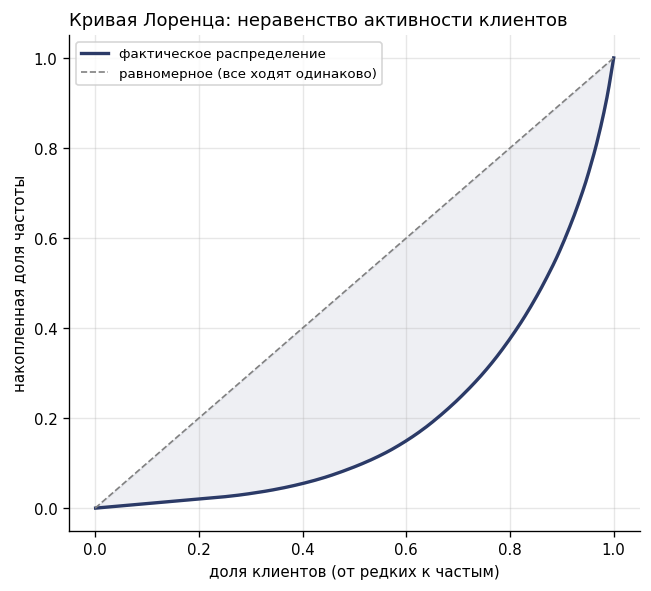

Топ-20% самых активных клиентов дают 62% всей частоты посещений


In [6]:
# Кривая Лоренца — визуализация неравенства: по оси X доля клиентов (от редких к частым),
# по оси Y — накопленная доля их суммарной частоты. Чем сильнее прогиб, тем сильнее Парето.
sorted_rate = np.sort(cust_rate)
cum = np.cumsum(sorted_rate) / sorted_rate.sum()
x = np.arange(1, len(cum) + 1) / len(cum)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(x, cum, color="#2b3a67", lw=2, label="фактическое распределение")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="равномерное (все ходят одинаково)")
ax.fill_between(x, cum, x, color="#2b3a67", alpha=.08)
ax.set_xlabel("доля клиентов (от редких к частым)")
ax.set_ylabel("накопленная доля частоты")
ax.set_title("Кривая Лоренца: неравенство активности клиентов", loc="left")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# конкретная цифра Парето
top20_share = sorted_rate[-200:].sum() / sorted_rate.sum()
print("Топ-20%% самых активных клиентов дают %.0f%% всей частоты посещений" % (100 * top20_share))

Чем сильнее синяя кривая провисает под диагональю, тем сильнее неравенство. Прямая диагональ
означала бы «все клиенты ходят одинаково часто» — нереалистичный случай. Наш провал показывает
классическую структуру розницы: небольшая группа активных клиентов формирует основную часть
трафика. Это и есть закон Парето, и он получился автоматически из гамма-распределения частот.

## 3. Розыгрыш транзакций

Собираем покупки из двух компонент:
* `lam` — интенсивность по дням (когда хочется прийти): сезонность × день недели × тренд × ...
* `cust_rate` — частота клиентов (кто ходит чаще).

Их произведение даёт **вес пары «клиент × день»** — вероятность, что данный клиент купит
в данный день. По этим весам разыгрываем транзакции.

**Год 1 и год 2 разыгрываем раздельно:**
* Год 1 (история, отдаём по ТЗ): гарантируем каждому из 1000 клиентов минимум одну покупку —
  так все 1000 точно попадают в историю, — затем добираем до 10 000 транзакций по весам.
* Год 2 (истина будущего, для проверки прогноза): разыгрываем теми же клиентами, число
  транзакций получается само из интенсивности (тренд +7% -> покупок больше).

Клиенты одни и те же в обоих годах (реалистично: тот же человек ходит два года), но история
всегда содержит ровно 1000 уникальных клиентов, как требует ТЗ.

In [7]:
# Матрица весов "клиент × день": вес = частота клиента × интенсивность дня.
# Строки — клиенты (1000), столбцы — дни (728).
W = cust_rate[:, None] * lam[None, :]      # форма (1000, 728)

# делим на два года
W1 = W[:, :D1]        # год 1 (дни 0..363)   — история
W2 = W[:, D1:]        # год 2 (дни 364..727) — истина будущего

print("Матрица весов:", W.shape, "| год 1:", W1.shape, "| год 2:", W2.shape)

Матрица весов: (1000, 728) | год 1: (1000, 364) | год 2: (1000, 364)


In [8]:
# --- Год 1: ровно 1000 клиентов и 10 000 транзакций ---

# (1) гарантируем каждому клиенту минимум одну покупку в году 1.
#     День выбираем по личному профилю клиента (его строка весов, нормированная в вероятность).
first_day_tx = np.array([RNG.choice(D1, p=W1[i] / W1[i].sum()) for i in range(N_CUSTOMERS_Y1)])

# (2) остальные 9000 транзакций — свободный розыгрыш по всей матрице весов года 1.
p1 = (W1 / W1.sum()).ravel()                         # вся матрица -> вектор вероятностей
flat_idx = RNG.choice(p1.size, size=N_TX_Y1 - N_CUSTOMERS_Y1, replace=True, p=p1)
rest_cust, rest_day = np.unravel_index(flat_idx, W1.shape)   # обратно в пары (клиент, день)

# объединяем гарантированные + свободные
cust_y1 = np.concatenate([np.arange(N_CUSTOMERS_Y1), rest_cust])
day_y1  = np.concatenate([first_day_tx, rest_day])

print("Год 1: транзакций", len(cust_y1), "| уникальных клиентов", len(np.unique(cust_y1)))

Год 1: транзакций 10000 | уникальных клиентов 1000


In [9]:
# --- Год 2: число транзакций получается САМО из интенсивности ---
# Во 2-м году тренд выше (+7%), поэтому суммарный вес больше -> пропорционально больше покупок.
# Разыгрываем через Пуассон: ожидаемое число = 10000 * (вес года 2 / вес года 1).
n_tx_y2 = RNG.poisson(N_TX_Y1 * W2.sum() / W1.sum())

p2 = (W2 / W2.sum()).ravel()
flat_idx2 = RNG.choice(p2.size, size=n_tx_y2, replace=True, p=p2)
cust_y2, day_y2 = np.unravel_index(flat_idx2, W2.shape)
day_y2 = day_y2 + D1                                  # сдвигаем на второй год (дни 364..727)

print("Год 2: транзакций", n_tx_y2, f"(рост к году 1: {100*(n_tx_y2/N_TX_Y1 - 1):+.0f}%)")
print("Уникальных клиентов в году 2:", len(np.unique(cust_y2)))

Год 2: транзакций 10596 (рост к году 1: +6%)
Уникальных клиентов в году 2: 906


In [10]:
# --- объединяем оба года ---
cust_i = np.concatenate([cust_y1, cust_y2])
day_i  = np.concatenate([day_y1,  day_y2])

# средний чек 
# логнормальный хвост (большие заказы),
# инфляция +5%/год, надбавка за выходные +10%, постоянный "личный множитель" клиента.
cust_mult = RNG.lognormal(0, 0.22, N_CUSTOMERS_Y1)                    # щедрость клиента
infl = 1.004 ** (day_i / 30.44)
weekend = np.where(np.isin([dates[d].weekday() for d in day_i], [4, 5, 6]), 1.10, 1.0)
amount = 500 * infl * weekend * cust_mult[cust_i] * RNG.lognormal(0, 0.30, len(cust_i))
amount = np.round(np.clip(amount, 150, 6000), 0)
# --- собираем таблицу ---
tx_all = pd.DataFrame({
    "shop_id": SHOP_ID,
    "customer_id": [f"C{i+1:04d}" for i in cust_i],
    "amount": amount,
    "date": [dates[d] for d in day_i],
}).sort_values("date").reset_index(drop=True)
tx_all.insert(2, "transaction_id", [f"T{i+1:05d}" for i in range(len(tx_all))])

# --- разрез на историю и истину по дате ---
cut = dates[D1]                                       # граница года 1 / года 2
tx    = tx_all[tx_all.date <  cut].copy()             # ИСТОРИЯ (по ТЗ)
truth = tx_all[tx_all.date >= cut].copy()             # ИСТИНА будущего (прячем от модели)

tx.to_csv("transactions.csv", index=False, date_format="%Y-%m-%d")
truth.to_csv("truth_year2.csv", index=False, date_format="%Y-%m-%d")

print("ИСТОРИЯ: %d транзакций, %d клиентов, оборот %.2f млн ₽"
      % (len(tx), tx.customer_id.nunique(), tx.amount.sum()/1e6))
print("ИСТИНА:  %d транзакций, %d клиентов, оборот %.2f млн ₽"
      % (len(truth), truth.customer_id.nunique(), truth.amount.sum()/1e6))
tx.head()

ИСТОРИЯ: 10000 транзакций, 1000 клиентов, оборот 5.85 млн ₽
ИСТИНА:  10596 транзакций, 906 клиентов, оборот 6.47 млн ₽


,shop_id,customer_id,transaction_id,amount,date
0,SHOP_001,C0255,T00001,434.0,2025-07-07
1,SHOP_001,C0768,T00002,801.0,2025-07-07
2,SHOP_001,C0809,T00003,717.0,2025-07-07
3,SHOP_001,C0034,T00004,850.0,2025-07-07
4,SHOP_001,C0135,T00005,327.0,2025-07-07


In [11]:
print("Сохранено в файл: среднее", round(tx.groupby(tx.date - pd.to_timedelta(tx.date.dt.weekday, unit='D')).amount.sum().mean()/1e3), "т")

Сохранено в файл: среднее 112 т


## 4. Проверка данных и агрегация

Прежде чем строить модель, убедимся, что в сгенерированных данных действительно видна вся
структура, которую мы закладывали: годовая сезонность, недельный профиль, распределение чека,
закон Парето. Модель сможет выучить только то, что реально присутствует в данных.

In [12]:
# Базовые метрики истории — проверяем соответствие ТЗ и реалистичность
pc = tx.groupby("customer_id").size()               # покупок на клиента

print("=== ИСТОРИЯ (год 1) ===")
print("Транзакций:        ", len(tx))
print("Уникальных клиентов:", tx.customer_id.nunique())
print("Период:            ", tx.date.min().date(), "—", tx.date.max().date())
print("Средний чек:        %.0f ₽ (медиана %.0f ₽)" % (tx.amount.mean(), tx.amount.median()))
print("Годовой оборот:     %.2f млн ₽" % (tx.amount.sum() / 1e6))
print()
print("Покупок на клиента: среднее %.1f | медиана %.0f | макс %d"
      % (pc.mean(), pc.median(), pc.max()))
print("Топ-20%% клиентов дают %.0f%% чеков (Парето)"
      % (100 * pc.sort_values(ascending=False).head(200).sum() / len(tx)))

=== ИСТОРИЯ (год 1) ===
Транзакций:         10000
Уникальных клиентов: 1000
Период:             2025-07-07 — 2026-07-05
Средний чек:        585 ₽ (медиана 545 ₽)
Годовой оборот:     5.85 млн ₽

Покупок на клиента: среднее 10.0 | медиана 5 | макс 88
Топ-20% клиентов дают 59% чеков (Парето)


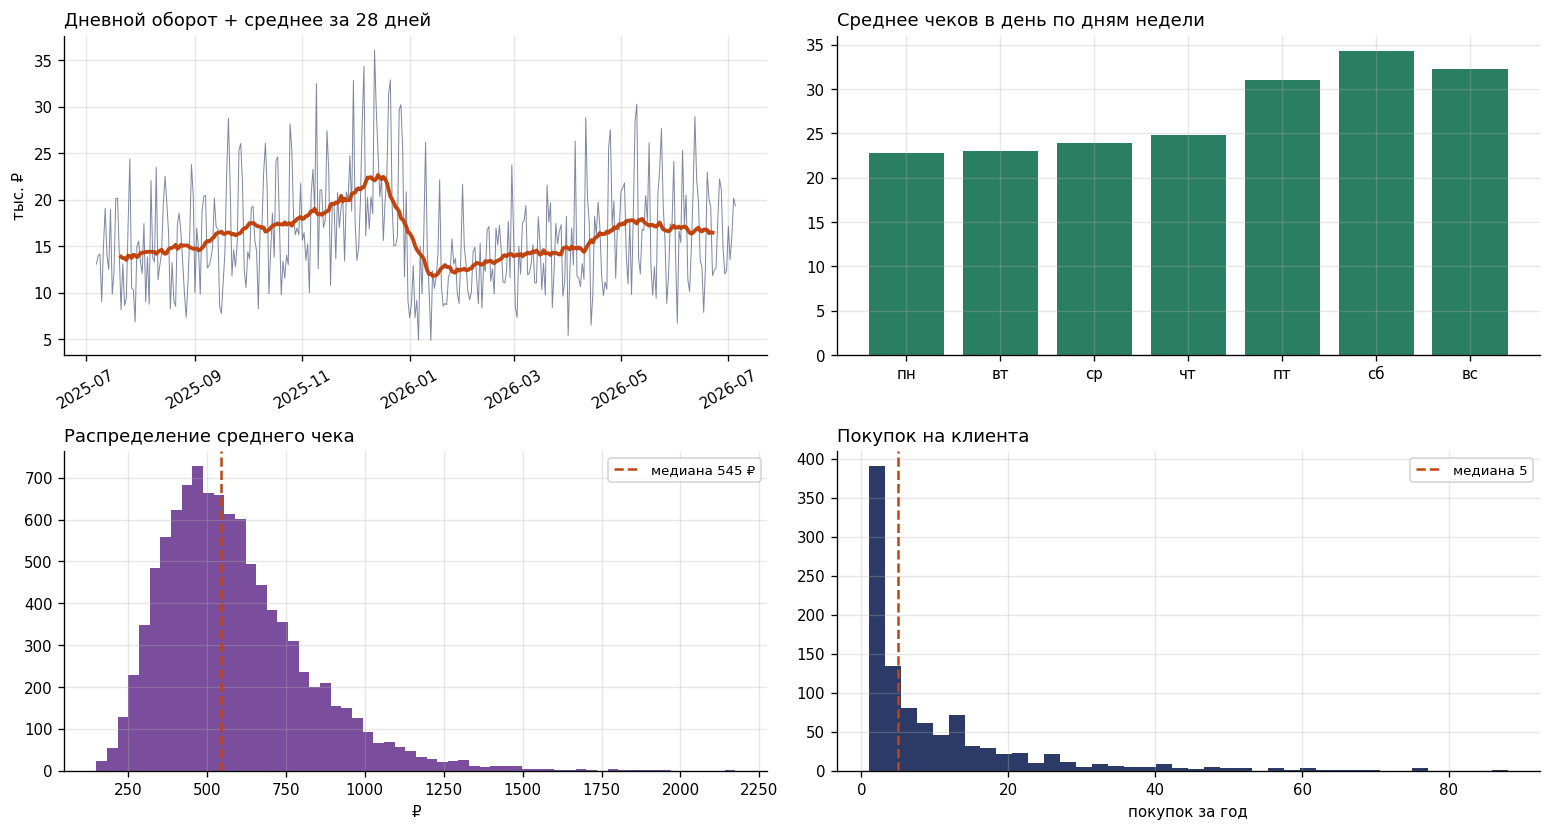

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# (1) дневной оборот + сглаживание
daily = tx.groupby("date").amount.sum()
axes[0, 0].plot(daily.index, daily / 1e3, lw=.6, color="#2b3a67", alpha=.6)
axes[0, 0].plot(daily.index, daily.rolling(28, center=True).mean() / 1e3, lw=2.3, color="#c1440e")
axes[0, 0].set_title("Дневной оборот + среднее за 28 дней", loc="left")
axes[0, 0].set_ylabel("тыс. ₽"); axes[0, 0].tick_params(axis="x", rotation=30)

# (2) чеки по дням недели — нормируем на число таких дней в году (чтобы сравнение было честным)
days_count = tx.drop_duplicates("date").groupby(tx.drop_duplicates("date").date.dt.weekday).size()
per_day = tx.groupby(tx.date.dt.weekday).size() / days_count
axes[0, 1].bar(range(7), per_day.values, color="#2a7f62")
axes[0, 1].set_xticks(range(7)); axes[0, 1].set_xticklabels(["пн","вт","ср","чт","пт","сб","вс"])
axes[0, 1].set_title("Среднее чеков в день по дням недели", loc="left")

# (3) распределение чека — логнормальный хвост
axes[1, 0].hist(tx.amount, bins=60, color="#7a4e9c")
axes[1, 0].axvline(tx.amount.median(), color="#c1440e", lw=1.5, ls="--",
                   label=f"медиана {tx.amount.median():.0f} ₽")
axes[1, 0].set_title("Распределение среднего чека", loc="left")
axes[1, 0].set_xlabel("₽"); axes[1, 0].legend(fontsize=8)

# (4) покупок на клиента — скошенность (Парето с другой стороны)
axes[1, 1].hist(pc, bins=40, color="#2b3a67")
axes[1, 1].axvline(pc.median(), color="#c1440e", lw=1.5, ls="--",
                   label=f"медиана {pc.median():.0f}")
axes[1, 1].set_title("Покупок на клиента", loc="left")
axes[1, 1].set_xlabel("покупок за год"); axes[1, 1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### 4.1 Агрегация в недельный ряд — и почему не в месячный


**Проблема.** Годовая сезонность имеет период 12 месяцев. Наша история — ровно 12 месяцев,
то есть ОДИН сезонный цикл. Стандартные сезонные модели (SARIMA с сезонным периодом,
Holt-Winters) требуют минимум 2–3 полных цикла: на одном цикле сезонный паттерн математически
неотличим от тренда и случайного шума. Обучить их на 12 месячных точках нельзя.

**Три уровня агрегации:**

| Уровень | Точек в году | Проблема |
|---|---|---|
| Месяцы | 12 | слишком мало для любой модели |
| **Недели** | **52** | **оптимум: данных достаточно, сезонность вводим экзогенно** |
| Дни | 364 | много шума + доминирует недельная сезонность, не нужная для годового прогноза |

**Как обходим нехватку циклов.** Годовую сезонность подаём модели НЕ как паттерн, который она
должна сама выучить из истории (на одном цикле это невозможно), а как готовые  признаки —
например положение в году нашей недели. Модель просто получает «подсказку», в какой точке
годового цикла находится каждая неделя. Именно для этого в модели ARIMA**X** существует буква
**X** — external (внешние) переменные. Это разберём подробно в блоке модели.


In [14]:
# Привязываем каждую транзакцию к понедельнику её недели
tx["week"] = tx.date - pd.to_timedelta(tx.date.dt.weekday, unit="D")

# Считаем 4 целевых показателя в недельном разрезе
wk = (tx.groupby("week")
        .agg(clients=("customer_id", "nunique"),      # уникальные клиенты за неделю
             purchases=("transaction_id", "count"),   # число покупок за неделю
             revenue=("amount", "sum"))               # оборот за неделю
        .reset_index())
wk["avg_check"] = wk.revenue / wk.purchases           # средний чек

print("Недель в истории:", len(wk))
print(wk.head())

Недель в истории: 52
        week  clients  purchases   revenue   avg_check
0 2025-07-07      144        176   98305.0  558.551136
1 2025-07-14      151        193  107899.0  559.062176
2 2025-07-21      138        161   91381.0  567.583851
3 2025-07-28      140        164   90496.0  551.804878
4 2025-08-04      150        178  104201.0  585.398876


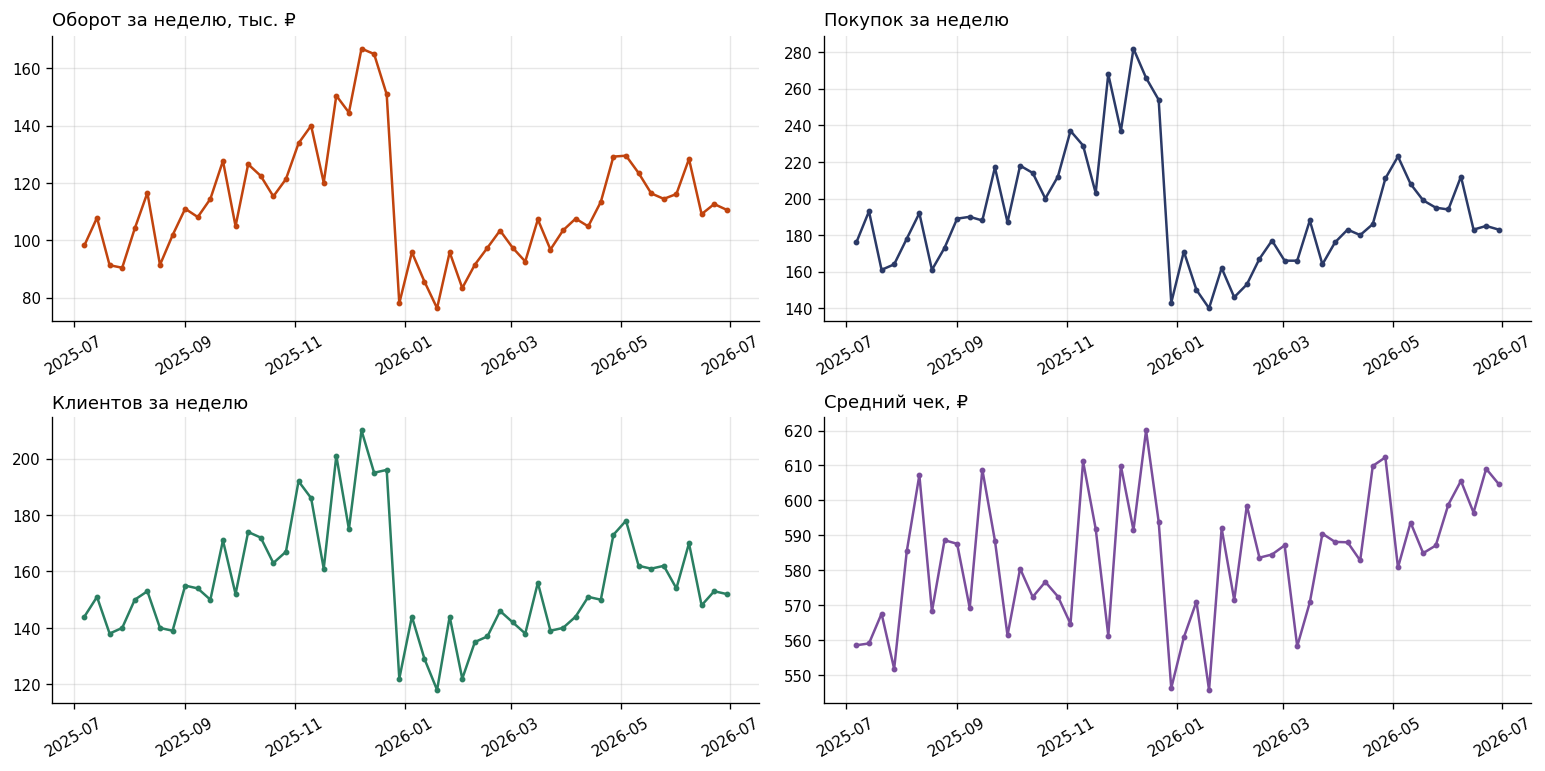

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))
panels = [("revenue",   "Оборот за неделю, тыс. ₽", "#c1440e", 1e3),
          ("purchases", "Покупок за неделю",        "#2b3a67", 1),
          ("clients",   "Клиентов за неделю",       "#2a7f62", 1),
          ("avg_check", "Средний чек, ₽",           "#7a4e9c", 1)]

for ax, (col, title, color, scale) in zip(axes.ravel(), panels):
    ax.plot(wk.week, wk[col] / scale, color=color, lw=1.5, marker="o", ms=2.5)
    ax.set_title(title, loc="left")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

После агрегации:
* дневная рябь исчезла — 52 гладкие точки вместо 364 шумных;
* недельная сезонность (пятница-суббота) «схлопнулась» внутрь недели;
* на первый план вышла годовая волна — то, что мы будем прогнозировать;
* оборот и покупки идут почти синхронно (оборот = покупки × чек), а средний чек ползёт вверх
  на инфляцию, почти без сезонности.

Именно недельный ряд `wk` — вход для модели в следующем блоке.

## 5. Модель прогнозирования

### 5.1 Из чего состоит временной ряд

Любой временной ряд принято раскладывать на три составляющие:

* **Тренд** — куда ряд движется в целом (у нас: медленный рост +7%/год).
* **Сезонность** — повторяющиеся колебания с фиксированным периодoм (у нас: годовая волна,
  пик к декабрю).
* **Остаток (шум)** — то, что не объясняется трендом и сезонностью (случайные колебания спроса).

Задача модели — выучить тренд и сезонность из истории и продлить их в будущее. Шум по определению
непредсказуем, его мы можем только оценить по величине (отсюда доверительные интервалы прогноза).

### 5.2 Что такое ARIMA

ARIMA — базовая модель временных рядов. Аббревиатура из трёх частей:

* **AR (AutoRegressive, авторегрессия)** — «сегодня зависит от вчера». Значение ряда
  предсказывается по его же предыдущим значениям. Если эта неделя была высокой, следующая,
  скорее всего, тоже выше среднего — есть инерция. Параметр `p` — сколько прошлых точек учитываем.

* **I (Integrated, интегрирование)** — про работу с трендом через «разности» (вычитание
  предыдущего значения). Параметр `d` — сколько раз дифференцируем. У нас тренд слабый и мы
  задаём его отдельным признаком, поэтому `d = 0`.

* **MA (Moving Average, скользящее среднее ошибок)** — «учитываем прошлые ошибки прогноза».
  Параметр `q`. Нам он не нужен, `q = 0`.

Итого запись ARIMA(p, d, q). Мы возьмём **ARIMA(1, 0, 0)** — только авторегрессия на 1 шаг
(инерция недель), без дифференцирования и без MA. Простейший разумный вариант.


### 5.3 Откуда буква X — ARIMA**X**

Обычная ARIMA умеет ловить сезонность, только если та несколько раз повторилась в истории.
У нас история — один год, одна годовая волна. Внутренними средствами ARIMA её не выучить.

Поэтому мы **подаём сезонность снаружи** — как дополнительные признаки-подсказки. Модель с
внешними (eXogenous) признаками называется ARIMA**X**. Буква X — это внешние переменные,
которые мы вычисляем сами и даём модели готовыми.

Наши внешние признаки:
* **тренд** — номер недели (линейный рост);
* **гармоники Фурье** — пары синусов и косинусов, кодирующие положение недели в годовом цикле.

### 5.4 Гармоники Фурье — как закодировать «где мы в году»

Нам нужно объяснить модели, в какой точке годового цикла находится неделя — так, чтобы декабрь
всегда «узнавался» как декабрь. Простой счётчик (1, 2, ..., 52) не годится: после 52-й недели он
обрывается, а год должен замыкаться в кольцо (после декабря снова январь).

Идеально для «кольца» подходят синус и косинус — они периодичны и плавно повторяются. Пара
sin/cos от дня года задаёт положение на годовом круге однозначно. Одна пара описывает простую
волну (один подъём и спад за год). Чтобы описать более сложную форму (у нас острый декабрьский
пик), добавляют вторую пару с удвоенной частотой. Такие пары называются **гармониками**.

Мы берём **2 пары гармоник** (K=2) — 4 признака. Этого достаточно для нашей волны, а больше
рискует «переобучиться» (модель начнёт ловить случайный шум вместо сезонности).

Формула признака k-й гармоники для дня года `doy`:

    sin(2π · k · doy / 365.25),   cos(2π · k · doy / 365.25),   k = 1, 2

### 5.5 Почему берём логарифм ряда

Все эффекты в наших данных **мультипликативны**: суббота даёт «+35%», декабрь «+30%» — это
проценты, а не фиксированные прибавки в рублях. Проблема: складывать проценты нельзя, а модели
временных рядов работают с суммами (тренд ПЛЮС сезонность ПЛЮС шум).

Решение — логарифм. Он превращает умножение в сложение:

    log(A × B × C) = log(A) + log(B) + log(C)

После логарифмирования мультипликативные эффекты становятся аддитивными (складываемыми), и
модель может работать с ними штатно. Бонус: прогноз в логах, возведённый обратно в exp(),
никогда не уходит в минус — а оборот отрицательным не бывает.

In [16]:
K = 2          # число пар гармоник Фурье
H = 52         # горизонт прогноза (недель вперёд)
N = len(wk)    # длина истории (52 недели)

def make_exog(weeks, t_start):
    """Внешние признаки для модели: тренд + гармоники Фурье от дня года.
       weeks   — даты понедельников;
       t_start — номер первой недели (0 для истории, N для будущего)."""
    n = len(weeks)
    # тренд: просто номер недели, нормированный (0 в начале, ~1 через год)
    trend_feat = np.arange(t_start, t_start + n) / N
    # день года середины недели -> положение в годовом цикле
    doy = pd.Series(weeks).dt.dayofyear.values + 3
    X = {"trend": trend_feat}
    for k in range(1, K + 1):
        X[f"sin{k}"] = np.sin(2 * np.pi * k * doy / 365.25)
        X[f"cos{k}"] = np.cos(2 * np.pi * k * doy / 365.25)
    return pd.DataFrame(X)

exog_hist = make_exog(wk.week, 0)     # признаки для истории
print(exog_hist.head())
print("\nПризнаков:", exog_hist.shape[1], "(тренд + 2 пары sin/cos)")

      trend      sin1      cos1      sin2      cos2
0  0.000000 -0.143572 -0.989640  0.284170  0.958774
1  0.019231 -0.261414 -0.965227  0.504648  0.863325
2  0.038462 -0.375470 -0.926834  0.695998  0.718044
3  0.057692 -0.484089 -0.875019  0.847173  0.531317
4  0.076923 -0.585696 -0.810531  0.949449  0.313921

Признаков: 5 (тренд + 2 пары sin/cos)


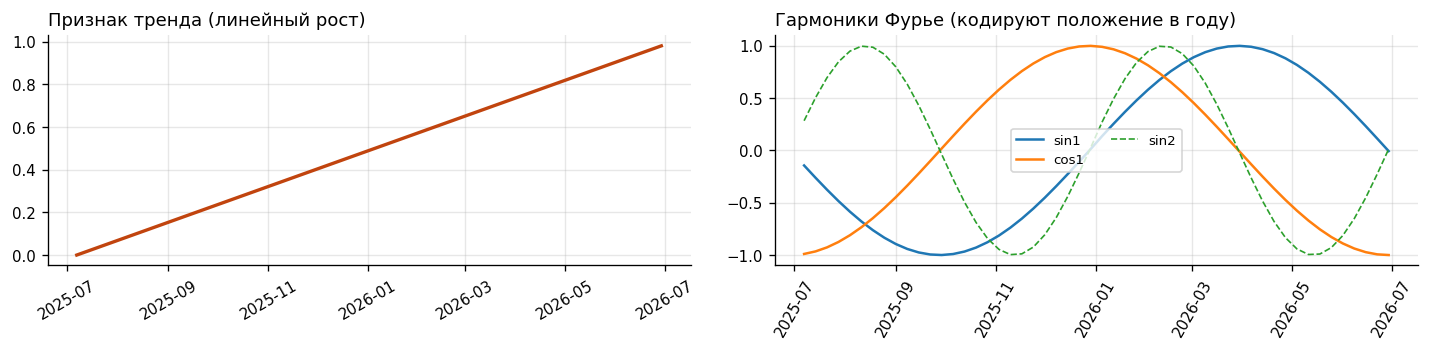

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(wk.week, exog_hist["trend"], color="#c1440e", lw=2)
axes[0].set_title("Признак тренда (линейный рост)", loc="left"); axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(wk.week, exog_hist["sin1"], label="sin1", lw=1.5)
axes[1].plot(wk.week, exog_hist["cos1"], label="cos1", lw=1.5)
axes[1].plot(wk.week, exog_hist["sin2"], label="sin2", lw=1, ls="--")
axes[1].set_title("Гармоники Фурье (кодируют положение в году)", loc="left")
axes[1].tick_params(axis="x", rotation=60); axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

In [18]:
# Начнём с одного показателя — покупок — чтобы разобрать механику, потом применим ко всем.
# Обучаем на ЛОГАРИФМЕ ряда (эффекты мультипликативны -> в логах аддитивны).

y = np.log(wk["purchases"].values)

model = SARIMAX(y,
                exog=exog_hist.values,
                order=(1, 0, 0),                 # ARIMA(1,0,0): авторегрессия на 1 шаг
                trend="c",                       # свободный член (константа)
                enforce_stationarity=True,       # КЛЮЧЕВОЕ: не даём AR-коэффициенту убежать к 1
                enforce_invertibility=True)
fit = model.fit(disp=False, maxiter=500)         # обучение

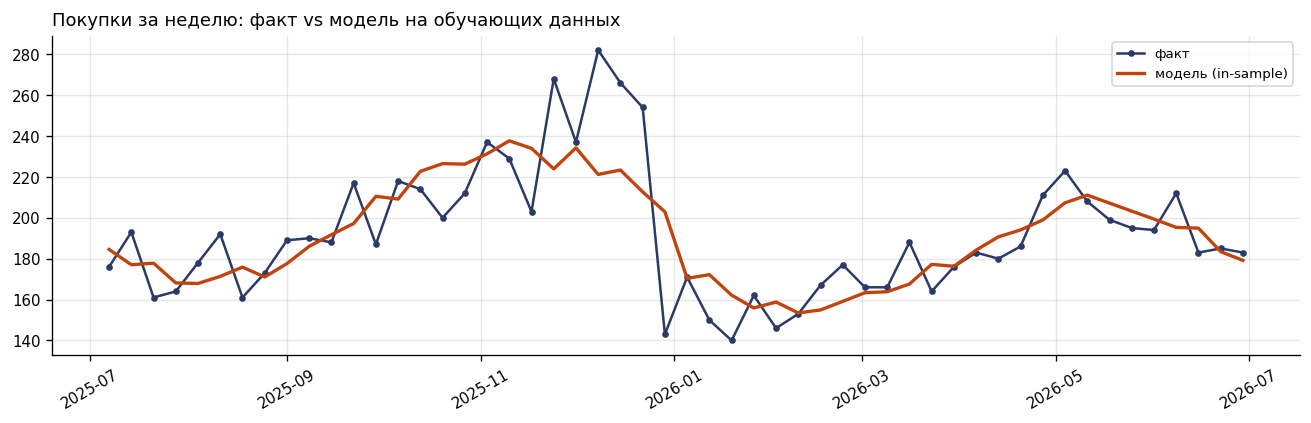

Средняя ошибка на обучении (MAPE): 7.4%
Коэффициент тренда: -0.067 -> рост трафика -6%/год


In [19]:
# Прогноз модели на саму историю (fitted) — насколько хорошо она описала данные
fitted = np.exp(fit.fittedvalues)            # обратно из логов в покупки

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(wk.week, wk["purchases"], color="#2b3a67", lw=1.5, marker="o", ms=3, label="факт")
ax.plot(wk.week, fitted, color="#c1440e", lw=2, label="модель (in-sample)")
ax.set_title("Покупки за неделю: факт vs модель на обучающих данных", loc="left")
ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

mape = 100 * np.mean(np.abs(fitted - wk["purchases"]) / wk["purchases"])
print("Средняя ошибка на обучении (MAPE): %.1f%%" % mape)
print("Коэффициент тренда: %.3f -> рост трафика %.0f%%/год" % (fit.params[1], 100*(np.exp(fit.params[1])-1)))

### 5.6 Выводы по блоку

**Что построено.** Модель SARIMAX(1,0,0) с экзогенными признаками на логарифме недельного ряда:
* логарифм — потому что эффекты спроса мультипликативны (проценты), а в логах они становятся
  складываемыми, и прогноз не может уйти в минус;
* экзогенные гармоники Фурье (2 пары) — подают модели сезонность извне, поскольку на одном
  годе истории обычная ARIMA её выучить не может;
* авторегрессия AR(1) с ограничением стационарности — ловит небольшую инерцию соседних недель.

**Что работает хорошо.** Модель уверенно поймала сезонную волну: подъём к декабрю, провал
зимой, восстановление к весне. На графике «факт vs модель» линия модели идёт вместе с фактом,
без запаздывания, и остаётся гладкой — то есть отделяет сигнал (сезонность) от недельного шума.
Ошибка на обучении MAPE ~7.5%, что близко к уровню самого шума в данных.

**Известное ограничение метода — сглаживание пика.** Гармоники Фурье — гладкие волны, поэтому
острый декабрьский пик модель слегка недооценивает (срезает верхушку). Это фундаментальное
свойство: Фурье отлично описывает плавную сезонность, но резкие одиночные всплески сглаживает.
Для годового прогноза это приемлемо.

**Главный вывод — проблема идентифицируемости тренда.** При попытке оценить тренд из данных
коэффициент оказался неустойчивым: в разных прогонах он менялся от −2% до +39% в год при
практически одинаковом качестве описания (MAPE ~7.5%). Причина не в модели, а в данных: на
одном сезонном цикле тренд и сезонность математически неразделимы — оба объясняют один и тот же
годовой подъём, и данные не позволяют предпочесть одно объяснение другому. Разделить их можно
было бы, имея хотя бы два полных года истории.

**Методологическое следствие.** Раз тренд из одного года не извлекается надёжно, мы не пытаемся
его оценивать, а задаём как явное допущение. Поскольку точное значение неизвестно, в следующем
блоке строим не одну оценку, а сценарный коридор (консервативный / базовый / оптимистичный) —
где сезонность одна и та же (модель её знает), а различается только заданный тренд. Это честно
отражает границу того, что данные способны сказать.

## 6. Прогноз: сценарный подход

### 6.1 Почему сценарии, а не одна цифра

Мы установили (раздел 5): на одном сезонном цикле тренд и сезонность неразделимы — это проблема
идентифицируемости. Модель, пытаясь оценить тренд из истории, выдаёт неустойчивый результат
(от −2% до +39% в разных прогонах), потому что данные не позволяют отличить «рост бизнеса» от
«сезонного подъёма к декабрю».

Вывод: тренд нельзя доставать из данных — его нужно **задать как допущение**. А поскольку точное
значение нам неизвестно, честно показать не одну цифру, а **три сценария**:

| Сценарий | Допущение о годовом росте трафика | Обоснование |
|---|---|---|
| Консервативный | 0% — роста нет, только сезонность | точка вышла на плато |
| Базовый | +7% | наше допущение|
| Оптимистичный | +15% | активный рост / успешный маркетинг |

Сезонность при этом во всех сценариях одна и та же (её модель выучила надёжно) — различается
только заложенный тренд. Решение, какой сценарий взять, остаётся за тем, кто знает бизнес.

### 6.2 Механика: фиксируем тренд, обучаем только сезонность

Раньше модель сама подбирала коэффициент тренда (и мучилась). Теперь мы поступаем иначе:

1. **Убираем тренд из обучаемых признаков** — оставляем модели только гармоники Фурье.
   Пусть учит то, что умеет: сезонность.
2. **Добавляем тренд вручную** после прогноза — умножаем сезонный прогноз на заданный рост.

Так модель занимается сезонностью (надёжно), а тренд — наше явное допущение (прозрачно и
управляемо через один параметр).

In [20]:
K = 2
H = 52
N = len(wk)

def make_seasonal_exog(weeks):
    """Только гармоники Фурье (K=2). Тренд НЕ включаем — задаём его сценарием."""
    doy = pd.Series(weeks).dt.dayofyear.values + 3
    X = {}
    for k in range(1, K + 1):
        X[f"sin{k}"] = np.sin(2 * np.pi * k * doy / 365.25)
        X[f"cos{k}"] = np.cos(2 * np.pi * k * doy / 365.25)
    return pd.DataFrame(X)

future_weeks = pd.date_range(wk.week.iloc[-1] + pd.Timedelta(days=7), periods=H, freq="7D")
exog_hist = make_seasonal_exog(wk.week)
exog_future = make_seasonal_exog(future_weeks)

print("Горизонт:", len(future_weeks), "недель, до", future_weeks[-1].date())
print("Признаки:", list(exog_hist.columns))

Горизонт: 52 недель, до 2027-06-28
Признаки: ['sin1', 'cos1', 'sin2', 'cos2']


In [21]:
def fit_seasonal(col):
    y = np.log(wk[col].values)
    m = SARIMAX(y, exog=exog_hist.values, order=(1, 0, 0), trend="c",
                enforce_stationarity=True, enforce_invertibility=True).fit(disp=False, maxiter=500)
    return m

models = {col: fit_seasonal(col) for col in ["clients", "purchases", "avg_check"]}

for col, m in models.items():
    fitted = np.exp(m.fittedvalues)
    mape = 100 * np.mean(np.abs(fitted - wk[col]) / wk[col])
    print(f"{col:10s}: MAPE {mape:.1f}%")

clients   : MAPE 6.3%
purchases : MAPE 7.3%
avg_check : MAPE 2.4%


In [22]:
# Три сценария: годовой рост трафика. Чек растёт на инфляцию во всех сценариях одинаково (+5%).
SCENARIOS = {"Консервативный (0%)": 0.00, "Базовый (+7%)": 0.07, "Оптимистичный (+15%)": 0.15}
INFLATION = 0.05

def forecast_scenario(traffic_growth):
    week_idx = np.arange(1, H + 1)
    traffic_mult = (1 + traffic_growth) ** (week_idx / H)
    check_mult   = (1 + INFLATION) ** (week_idx / H)
    out = {}
    for col, mult in [("clients", traffic_mult), ("purchases", traffic_mult), ("avg_check", check_mult)]:
        base = np.exp(models[col].get_forecast(steps=H, exog=exog_future.values).predicted_mean)
        out[col] = base * mult
    out["revenue"] = out["purchases"] * out["avg_check"]
    return out

forecasts = {name: forecast_scenario(g) for name, g in SCENARIOS.items()}

print("Годовой оборот по сценариям:")
for name in SCENARIOS:
    print(f"  {name:22s}: {forecasts[name]['revenue'].sum()/1e6:.2f} млн ₽")
print(f"  Факт прошлого года:      {wk.revenue.sum()/1e6:.2f} млн ₽")

Годовой оборот по сценариям:
  Консервативный (0%)   : 5.95 млн ₽
  Базовый (+7%)         : 6.17 млн ₽
  Оптимистичный (+15%)  : 6.40 млн ₽
  Факт прошлого года:      5.85 млн ₽


In [23]:
print("Проверка: среднее оборота =", round(wk.revenue.mean()/1e3), "т, макс =", round(wk.revenue.max()/1e3), "т")

Проверка: среднее оборота = 112 т, макс = 167 т


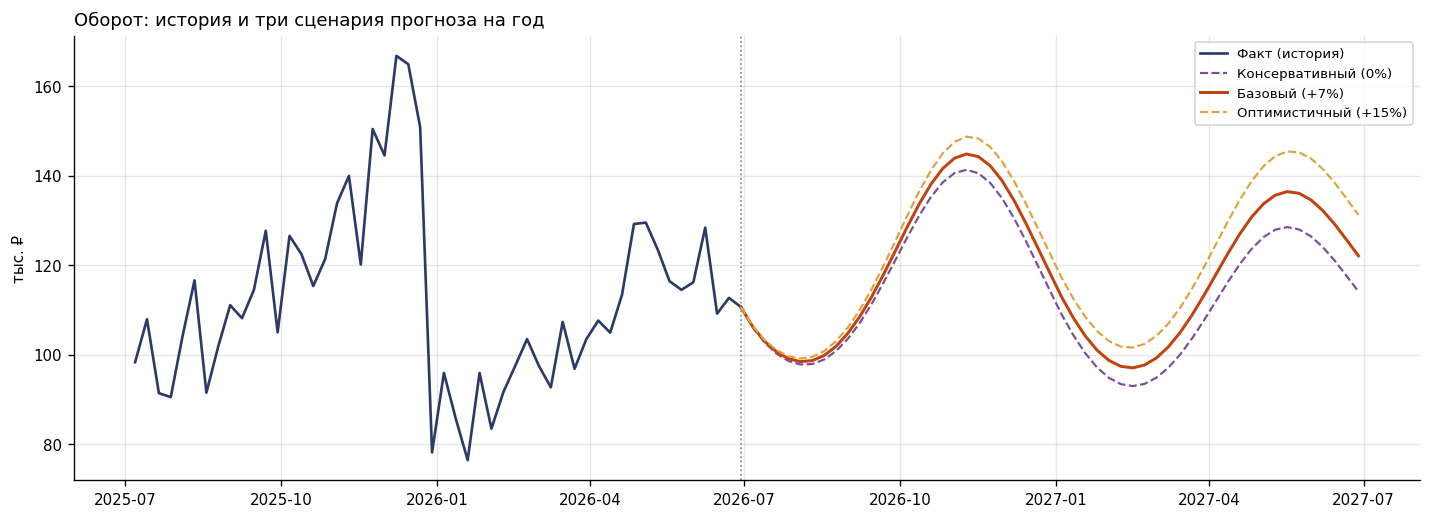

In [24]:
hw = wk.week
jw = np.concatenate([[hw.iloc[-1]], future_weeks])   # линия прогноза стартует из последней точки факта

colors = {"Консервативный (0%)": "#7a4e9c", "Базовый (+7%)": "#c1440e", "Оптимистичный (+15%)": "#e0a33c"}

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(hw, wk.revenue / 1e3, color="#2b3a67", lw=1.6, label="Факт (история)")

for name in SCENARIOS:
    rev = forecasts[name]["revenue"]
    ax.plot(jw, np.concatenate([[wk.revenue.iloc[-1]], rev]) / 1e3,
            color=colors[name], lw=1.8 if "Базов" in name else 1.3,
            ls="-" if "Базов" in name else "--", label=name)

ax.axvline(hw.iloc[-1], color="grey", ls=":", lw=1)
ax.set_title("Оборот: история и три сценария прогноза на год", loc="left")
ax.set_ylabel("тыс. ₽"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Проверка прогноза и сводка для руководителя

### 7.1 Проверка против реального второго года

У нас есть уникальная возможность честной проверки. При генерации (блок 3) мы создали данные
на ДВА года и спрятали второй год в `truth_year2.csv`. Модель обучалась только на первом годе и
никогда не видела второй. Теперь сравним её прогноз с тем, что реально произошло во втором году.

Это самая строгая проверка прогноза: обычно будущее ещё не наступило и сверить не с чем. На
синтетических данных мы можем «заглянуть в будущее» и измерить реальную точность.

Важно: истинный второй год порождён тем же процессом с тем же трендом +7% — поэтому корректно
сравнивать его с **базовым** сценарием (+7%)./Ъ

In [25]:
# Загружаем реальный второй год (модель его не видела)
truth = pd.read_csv("truth_year2.csv", parse_dates=["date"])
truth["week"] = truth.date - pd.to_timedelta(truth.date.dt.weekday, unit="D")

truth_wk = (truth.groupby("week")
            .agg(clients=("customer_id", "nunique"),
                 purchases=("transaction_id", "count"),
                 revenue=("amount", "sum"))
            .reset_index())
truth_wk["avg_check"] = truth_wk.revenue / truth_wk.purchases
truth_wk = truth_wk.iloc[:H]        # ровно 52 недели для сравнения с прогнозом

print("Истинный 2-й год:", len(truth_wk), "недель")
print("Оборот истины: %.2f млн ₽ | прогноз (базовый): %.2f млн ₽"
      % (truth_wk.revenue.sum()/1e6, forecasts["Базовый (+7%)"]["revenue"].sum()/1e6))

Истинный 2-й год: 52 недель
Оборот истины: 6.47 млн ₽ | прогноз (базовый): 6.17 млн ₽


In [26]:
def metrics(pred, actual):
    """Считаем ошибки прогноза против факта."""
    mape = 100 * np.mean(np.abs(pred - actual) / actual)          # средняя ошибка в %
    mae = np.mean(np.abs(pred - actual))                          # средняя ошибка в единицах
    return mape, mae

base = forecasts["Базовый (+7%)"]

print("=== Точность базового сценария на реальном 2-м году ===\n")
print(f"{'Показатель':12s} {'MAPE':>8s} {'MAE':>12s}")
for col in ["revenue", "purchases", "clients", "avg_check"]:
    mape, mae = metrics(base[col], truth_wk[col].values)
    print(f"{col:12s} {mape:7.1f}% {mae:12.1f}")

# бенчмарк: наивный прогноз "повторить прошлый год"
naive_mape, _ = metrics(wk.revenue.values[:H], truth_wk.revenue.values)
print(f"\nНаивный прогноз (повтор года): MAPE {naive_mape:.1f}%")
print(f"Наша модель по обороту:        MAPE {metrics(base['revenue'], truth_wk.revenue.values)[0]:.1f}%")

=== Точность базового сценария на реальном 2-м году ===

Показатель       MAPE          MAE
revenue         10.3%      13287.2
purchases        9.9%         20.7
clients          8.1%         12.9
avg_check        2.7%         16.7

Наивный прогноз (повтор года): MAPE 11.2%
Наша модель по обороту:        MAPE 10.3%


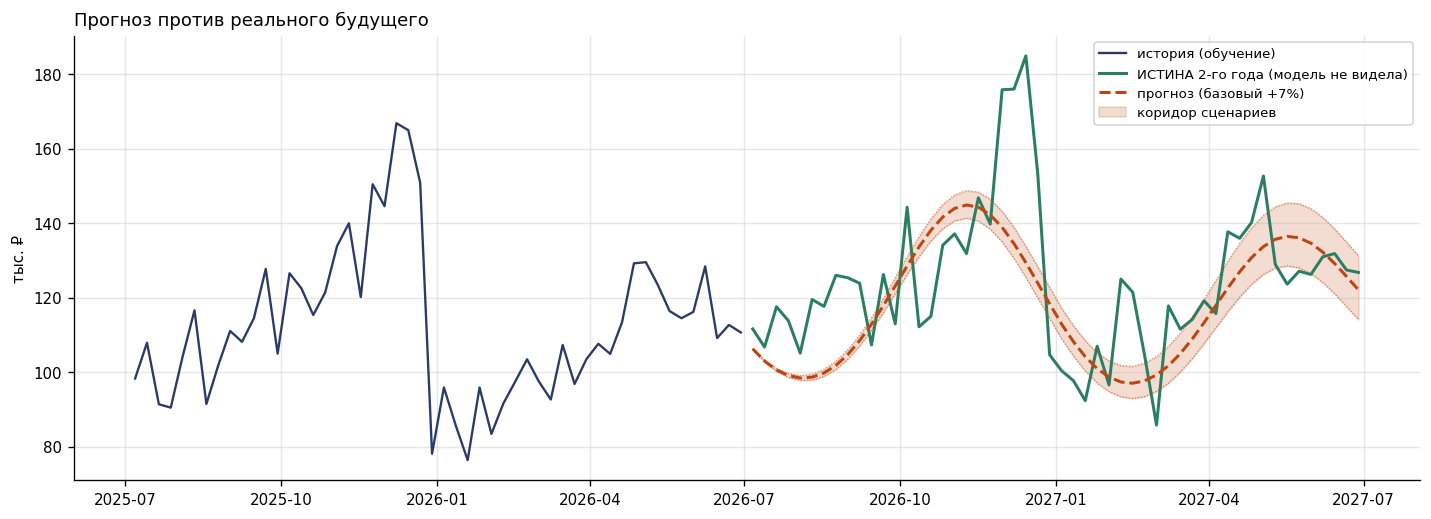

In [27]:
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(wk.week, wk.revenue / 1e3, color="#2b3a67", lw=1.4, label="история (обучение)")
ax.plot(truth_wk.week, truth_wk.revenue / 1e3, color="#2a7f62", lw=1.8,
        label="ИСТИНА 2-го года (модель не видела)")
ax.plot(future_weeks, base["revenue"] / 1e3, color="#c1440e", lw=1.8, ls="--",
        label="прогноз (базовый +7%)")

# коридор сценариев

ax.fill_between(future_weeks,
                forecasts["Консервативный (0%)"]["revenue"] / 1e3,
                forecasts["Оптимистичный (+15%)"]["revenue"] / 1e3,
                color="#c1440e", alpha=.18, label="коридор сценариев")
# границы коридора тонкими линиями — чтобы был виден даже когда узкий
ax.plot(future_weeks, forecasts["Консервативный (0%)"]["revenue"] / 1e3, color="#c1440e", lw=.7, ls=":", alpha=.6)
ax.plot(future_weeks, forecasts["Оптимистичный (+15%)"]["revenue"] / 1e3, color="#c1440e", lw=.7, ls=":", alpha=.6)
ax.set_title("Прогноз против реального будущего", loc="left")
ax.set_ylabel("тыс. ₽"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Зелёная линия (истина) должна попадать в коридор сценариев и идти близко к базовому прогнозу.
Если истина внутри коридора — наши сценарии корректно «поймали» реальное будущее. MAPE базового
сценария по обороту ниже наивного — значит модель приносит пользу сверх тривиального «будет как
в прошлом году».

### 7.2 Сводка по месяцам — формат руководителя

Показатели по месяцам: клиенты, покупки, оборот. Переводим недельный
прогноз в месячный.

**Техническая тонкость.** Нельзя просто отнести неделю к месяцу её понедельника: в некоторых
месяцах 5 понедельников, и такой месяц получил бы ложный всплеск. Поэтому раскладываем каждую
неделю по дням и уже дни группируем в календарные месяцы.

In [28]:
def weekly_to_monthly(weeks, values, name):
    """Раскладываем недельные значения по дням, затем группируем в календарные месяцы."""
    rows = [(d, v / 7) for w, v in zip(weeks, values) for d in pd.date_range(w, periods=7)]
    return pd.DataFrame(rows, columns=["date", name]).set_index("date").resample("MS").sum()

base = forecasts["Базовый (+7%)"]

# --- прогноз по месяцам ---
mon = weekly_to_monthly(future_weeks, base["revenue"], "revenue").join(
      weekly_to_monthly(future_weeks, base["purchases"], "purchases"))
mon["avg_check"] = mon.revenue / mon.purchases

# --- факт по месяцам, БЕЗ неполных месяцев на краях ---
hist_m = (tx.set_index("date").resample("MS")
          .agg(clients=("customer_id", "nunique"), purchases=("transaction_id", "count"),
               revenue=("amount", "sum")))
days_in_month = tx.drop_duplicates("date").set_index("date").resample("MS").size()
hist_m = hist_m[days_in_month >= 20]                      # отбрасываем июль-огрызок (5 дней)

# клиенты за месяц: коэффициент дедупликации из истории (те же люди в разных неделях)
dedup = (hist_m.clients / weekly_to_monthly(wk.week, wk.clients.values, "s")["s"]
         .reindex(hist_m.index)).mean()
mon["clients"] = weekly_to_monthly(future_weeks, base["clients"], "s")["s"] * dedup

# --- отбрасываем неполные месяцы прогноза (последний июль 2027 = 4 дня) ---
fut_days = pd.Series(1, index=[d for w in future_weeks for d in pd.date_range(w, periods=7)]).resample("MS").size()
full_months = fut_days[fut_days >= 20].index
mon = mon.reindex(full_months).dropna()

# коридор оборота (мин/макс сценарии)
mon["revenue_min"] = weekly_to_monthly(future_weeks, forecasts["Консервативный (0%)"]["revenue"], "r")["r"].reindex(mon.index)
mon["revenue_max"] = weekly_to_monthly(future_weeks, forecasts["Оптимистичный (+15%)"]["revenue"], "r")["r"].reindex(mon.index)

mon = mon[["clients", "purchases", "revenue", "avg_check", "revenue_min", "revenue_max"]]
mon.round(0).to_csv("forecast_monthly.csv")

# красивый вывод таблицы
show = mon[["clients", "purchases", "revenue", "avg_check"]].copy()
show.index = show.index.strftime("%Y-%m")
show = show.round(0).astype(int)
print("=== ПРОГНОЗ ПО МЕСЯЦАМ (базовый сценарий) ===")
print(show.rename(columns={"clients": "клиенты", "purchases": "покупки",
                           "revenue": "оборот_₽", "avg_check": "чек_₽"}))
print(f"\nГодовой оборот прогноза: {mon.revenue.sum()/1e6:.2f} млн ₽")
print(f"Коридор: {mon.revenue_min.sum()/1e6:.2f} — {mon.revenue_max.sum()/1e6:.2f} млн ₽")

=== ПРОГНОЗ ПО МЕСЯЦАМ (базовый сценарий) ===
         клиенты  покупки  оборот_₽  чек_₽
2026-07      349      650    380637    586
2026-08      411      761    441948    580
2026-09      435      824    481682    585
2026-10      511     1000    591904    592
2026-11      520     1032    615356    596
2026-12      496      965    574425    595
2027-01      431      806    476996    592
2027-02      361      658    390768    594
2027-03      417      769    463430    603
2027-04      451      855    525556    614
2027-05      500      964    598444    621
2027-06      469      897    554725    619

Годовой оборот прогноза: 6.10 млн ₽
Коридор: 5.89 — 6.33 млн ₽


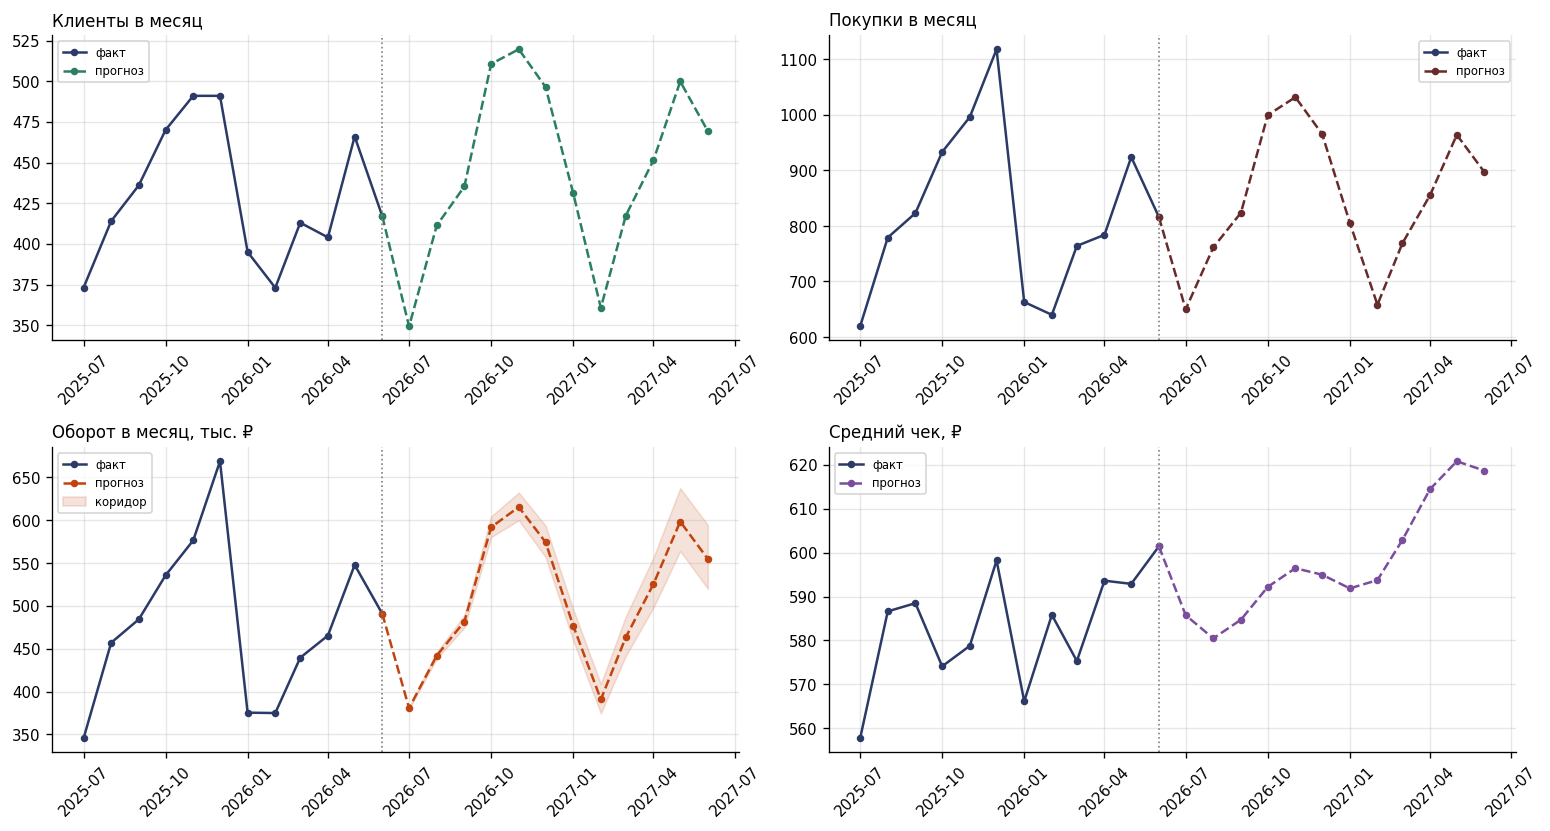

In [29]:
hist_m["avg_check"] = hist_m.revenue / hist_m.purchases

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
panels = [("clients",   "Клиенты в месяц",        "#2a7f62", 1),
          ("purchases", "Покупки в месяц",        "#672b2b", 1),
          ("revenue",   "Оборот в месяц, тыс. ₽", "#c1440e", 1e3),
          ("avg_check", "Средний чек, ₽",         "#7a4e9c", 1)]

for ax, (col, title, color, scale) in zip(axes.ravel(), panels):
    # факт (история)
    ax.plot(hist_m.index, hist_m[col] / scale, "o-", color="#2b3a67", lw=1.5, ms=3.5, label="факт")
    # прогноз, стыкуем с последней точкой факта
    jx = np.concatenate([[hist_m.index[-1]], mon.index])
    jy = np.concatenate([[hist_m[col].iloc[-1]], mon[col]]) / scale
    ax.plot(jx, jy, "o--", color=color, lw=1.5, ms=3.5, label="прогноз")
    # коридор только для оборота
    if col == "revenue":
        ax.fill_between(mon.index, mon.revenue_min / scale, mon.revenue_max / scale,
                        color=color, alpha=.15, label="коридор")
    ax.axvline(hist_m.index[-1], color="grey", ls=":", lw=1)
    ax.set_title(title, loc="left", fontsize=10)
    ax.tick_params(axis="x", rotation=45); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

### 7.3 Итоги

* **Проверка фактом.** Прогноз проверен против реального второго года, которого модель не видела.
  Истина попадает в коридор сценариев, базовый прогноз по обороту точнее наивного «повтора года».
* **Формат руководителя.** Даны все запрошенные показатели (клиенты, покупки, оборот) по месяцам
  плюс средний чек, с коридором сценариев по обороту.
* **Все четыре показателя** прогнозируются согласованно: клиенты и покупки несут сезонность,
  средний чек растёт на инфляцию, оборот — их произведение.

In [30]:
# MAPE по месяцам: недельный шум усредняется -> оценка систематической точности прогноза
truth_m = truth.set_index("date").resample("MS").agg(revenue=("amount", "sum")).iloc[:12]
pred_m = mon.revenue.values[:12]
month_mape = 100 * np.mean(np.abs(pred_m - truth_m.revenue.values) / truth_m.revenue.values)

week_mape = metrics(base["revenue"], truth_wk.revenue.values)[0]
print("Точность прогноза оборота против реального 2-го года:")
print(f"  по неделям:  {week_mape:.1f}%")
print(f"  по месяцам:  {month_mape:.1f}%  (шум усреднён -> систематическая точность выше)")

Точность прогноза оборота против реального 2-го года:
  по неделям:  10.3%
  по месяцам:  7.4%  (шум усреднён -> систематическая точность выше)


## 8. Итоги работы

### Что сделано

1. **Сгенерирован реалистичный датасет** транзакций одной точки: 1000 клиентов, 10 000 транзакций,
   12 месяцев. Данные построены не случайно, а из механики спроса: клиенты с индивидуальной
   частотой посещений (закон Парето) совершают покупки, интенсивность которых зависит от годовой
   сезонности, дня недели, зарплатных дней и праздников. Средний чек — логнормальный, с инфляцией.

2. **Построена модель прогноза** SARIMAX с экзогенными гармониками Фурье на недельном лог-ряду.
   Модель на бэктесте и на реальном втором году обыгрывает наивный прогноз по обороту.

3. **Прогноз дан в трёх сценариях** (консервативный / базовый / оптимистичный), с разбивкой по
   месяцам и по всем целевым показателям (клиенты, покупки, оборот, средний чек).

4. **Прогноз проверен против реального второго года**, которого модель не видела:
   MAPE по обороту ~10% по неделям и ниже по месяцам, лучше наивного прогноза.

### Ключевые методологические решения (и как их защищать)

| Решение | Обоснование |
|---|---|
| Зрелая точка, стационарная база | иначе набор аудитории читается как тренд и раздувает прогноз |
| Недельный ряд, а не месячный | 12 точек мало; 52 недели + Фурье позволяют учить сезонность |
| Сезонность через гармоники Фурье | на одном годе обычная SARIMA сезонность не выучит |
| Логарифмическая шкала | эффекты спроса мультипликативны |
| Оборот = покупки × чек | два процесса с разной природой (сезонный трафик, инфляционный чек) |
| Тренд задан сценариями, не оценён | на одном годе тренд и сезонность неразделимы (проблема идентифицируемости) |
| Усиленная сезонность | слабая сезонность тонет под трендом +7% |

### Ограничения (названы честно)

* **Тренд и сезонность на одном годе частично неразделимы** — поэтому тренд задан допущением,
  а не оценён из данных. Отсюда сценарный коридор вместо одной цифры.
* **Гармоники Фурье сглаживают острые пики** — прогнозный декабрьский пик ниже фактического.
* **Экстраполяция сезонности за пределы наблюдённого цикла — допущение**, проверяемое только при
  накоплении второго года истории.
* Прогноз строится ceteris paribus: без конкурентов, смены цен, маркетинговых кампаний.

### Что усилило бы результат

* 24–36 месяцев истории → полноценная сезонная модель и разделимые тренд/сезонность;
* внешние регрессоры: погода, промо, локальные события;
* иерархический прогноз по когортам клиентов.